In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

le = LabelEncoder()

train['Activity'] = le.fit_transform(train['Activity'])
test['Activity'] = le.transform(test['Activity'])

X_train = train.drop('Activity', axis=1)
X_test = test.drop('Activity', axis=1)

y_train = train['Activity']
y_test = test['Activity']
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8786559533802216


In [3]:
import pickle

In [4]:
with open('model_pickle','wb') as file:
    pickle.dump(model,file)

In [5]:
with open('model_pickle','rb') as file:
    mp = pickle.load(file)

In [6]:
mp.coef_

array([ 4.54065230e-01, -9.77573059e-01,  1.47802859e-02,  8.60563722e+00,
        4.75555732e+00,  6.89939119e+00, -4.10680139e+00, -1.17319481e+00,
       -2.47446286e-01, -3.07174627e-01,  7.58014473e-02,  4.72279136e-01,
        2.37541930e-01,  2.61153810e-02, -2.77392041e-01,  2.05784262e-01,
       -4.52042094e+05, -3.27248304e+05, -1.58590231e+05,  2.87189267e-01,
        3.10019134e-02,  4.23698715e-01, -2.06861152e-01, -1.78353022e-02,
       -5.03991278e-02,  8.58061146e-01,  1.13371825e+00, -1.92369184e-01,
       -4.13097660e-01,  1.37746429e-02,  5.31828001e-01,  4.76103647e-01,
        4.06236351e-01, -7.18375219e-01, -8.99650156e-01,  1.75037018e-01,
        6.01470139e-01, -1.42695431e-01, -6.72955606e-02, -5.08875238e-02,
        4.45481998e-02, -2.36270496e+00,  2.90765719e+00, -5.12536407e+00,
       -1.39080607e-01, -3.68216961e+00,  1.62013214e+00,  5.37232988e-01,
        3.66750568e+00,  1.24223510e+00,  1.19734251e+00,  4.90996090e-02,
       -6.27257552e-01, -

In [7]:
mp.intercept_

np.float64(1570713.0522251674)

In [9]:
mp.predict(X_test.iloc[0:1])

array([2.13358419])

In [11]:
import joblib

In [12]:
joblib.dump(model, 'model_joblib')

['model_joblib']

In [13]:
mj = joblib.load('model_joblib')

In [14]:
mj.coef_

array([ 4.54065230e-01, -9.77573059e-01,  1.47802859e-02,  8.60563722e+00,
        4.75555732e+00,  6.89939119e+00, -4.10680139e+00, -1.17319481e+00,
       -2.47446286e-01, -3.07174627e-01,  7.58014473e-02,  4.72279136e-01,
        2.37541930e-01,  2.61153810e-02, -2.77392041e-01,  2.05784262e-01,
       -4.52042094e+05, -3.27248304e+05, -1.58590231e+05,  2.87189267e-01,
        3.10019134e-02,  4.23698715e-01, -2.06861152e-01, -1.78353022e-02,
       -5.03991278e-02,  8.58061146e-01,  1.13371825e+00, -1.92369184e-01,
       -4.13097660e-01,  1.37746429e-02,  5.31828001e-01,  4.76103647e-01,
        4.06236351e-01, -7.18375219e-01, -8.99650156e-01,  1.75037018e-01,
        6.01470139e-01, -1.42695431e-01, -6.72955606e-02, -5.08875238e-02,
        4.45481998e-02, -2.36270496e+00,  2.90765719e+00, -5.12536407e+00,
       -1.39080607e-01, -3.68216961e+00,  1.62013214e+00,  5.37232988e-01,
        3.66750568e+00,  1.24223510e+00,  1.19734251e+00,  4.90996090e-02,
       -6.27257552e-01, -

In [15]:
mj.intercept_

np.float64(1570713.0522251674)

In [17]:
mj.predict(X_test.iloc[0:1])

array([2.13358419])

In [20]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

X_train = train[['Activity']]
X_test = test[['Activity']]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_train = encoder.fit_transform(X_train)
encoded_test = encoder.transform(X_test)

encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(['Activity'])
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(['Activity'])
)

train_final = pd.concat([train, encoded_train_df], axis=1)
test_final = pd.concat([test, encoded_test_df], axis=1)

print(train_final.head())
print(test_final.head())

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  angle(Y,grav

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv("/content/metadata.csv")

X = data['labelfile']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", len(X_train))
print("X_test  :", len(X_test))
print("y_train :", len(y_train))
print("y_test  :", len(y_test))

X_train : 571
X_test  : 143
y_train : 571
y_test  : 143


Saving HR_comma_sep.csv to HR_comma_sep (1).csv
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      

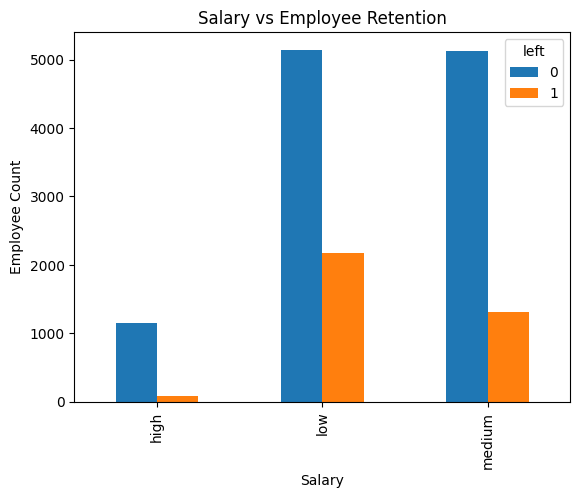

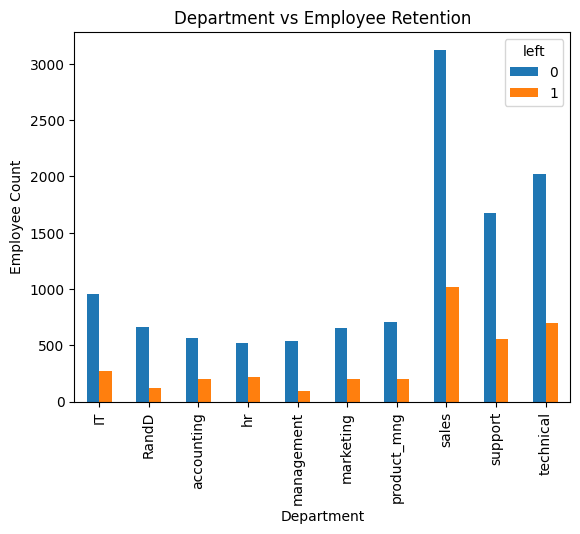

Accuracy : 0.762
[[2124  170]
 [ 544  162]]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2294
           1       0.49      0.23      0.31       706

    accuracy                           0.76      3000
   macro avg       0.64      0.58      0.58      3000
weighted avg       0.72      0.76      0.73      3000



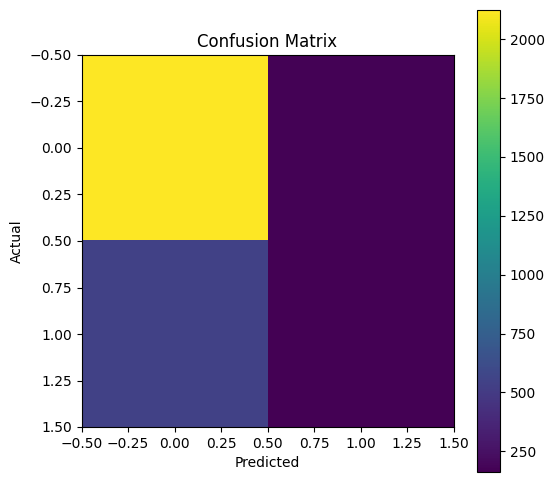

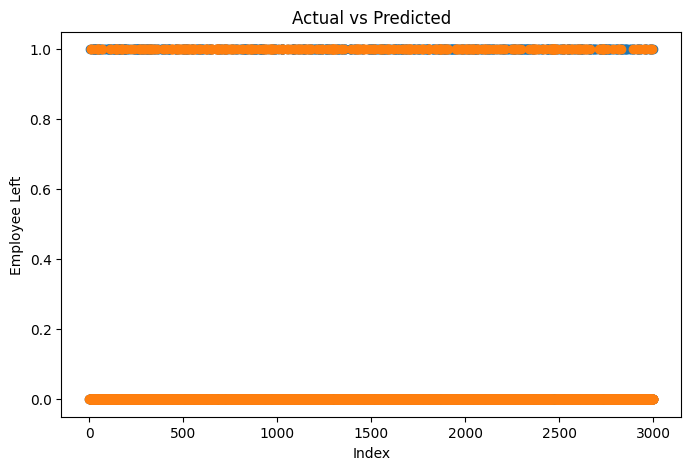

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


uploaded = files.upload()

df = pd.read_csv("/content/HR_comma_sep.csv")

print(df.head())

print(df.info())

print(df.describe())


left = df[df['left'] == 1]

retained = df[df['left'] == 0]

print(left.shape)
print(retained.shape)


print(df.groupby('left').mean(numeric_only=True))


pd.crosstab(df['salary'], df['left']).plot(kind='bar')

plt.xlabel("Salary")
plt.ylabel("Employee Count")
plt.title("Salary vs Employee Retention")

plt.show()


pd.crosstab(df['Department'], df['left']).plot(kind='bar')

plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.title("Department vs Employee Retention")

plt.show()


subdf = df[[
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'salary'
]]


salary_dummies = pd.get_dummies(
    subdf['salary'],
    prefix='salary'
)


df_with_dummies = pd.concat(
    [subdf, salary_dummies],
    axis=1
)


df_with_dummies.drop('salary', axis=1, inplace=True)


X = df_with_dummies

y = df['left']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)


cm = confusion_matrix(y_test, y_pred)

print(cm)

print(classification_report(y_test, y_pred))


plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test)

plt.scatter(range(len(y_pred)), y_pred)

plt.xlabel("Index")
plt.ylabel("Employee Left")

plt.title("Actual vs Predicted")

plt.show()